In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

In [28]:
!pip install librosa torch seaborn --quiet

import numpy as np
import pandas as pd
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score,confusion_matrix,classification_report,accuracy_score

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [30]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

GENRES_PATH = f"{DATA_PATH}/genres_stems"

ESC_PATH = f"{DATA_PATH}/ESC-50-master/audio"

# Dataset Exploration (EDA)

In [31]:
genre = "rock"
song_folder = os.listdir(f"{GENRES_PATH}/{genre}")[0]
file_path = f"{GENRES_PATH}/{genre}/{song_folder}/vocals.wav"
audio, sr = librosa.load(file_path, sr=None)
print(sr, len(audio)/sr)


44100 30.013333333333332


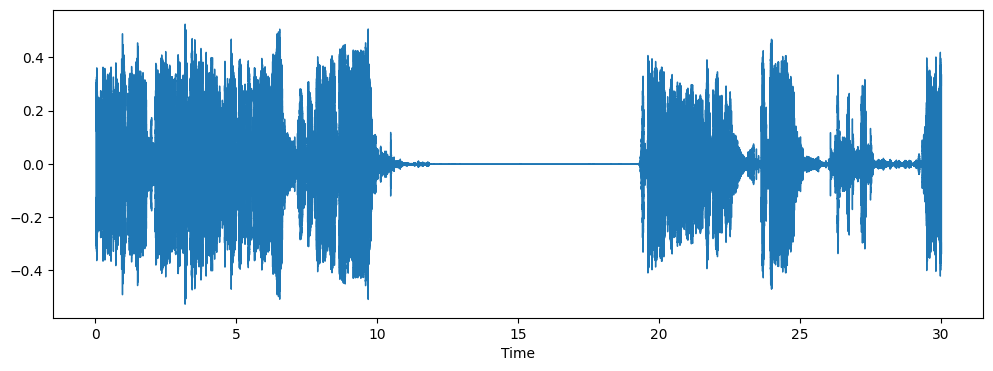

In [32]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(audio, sr=sr)
plt.show()


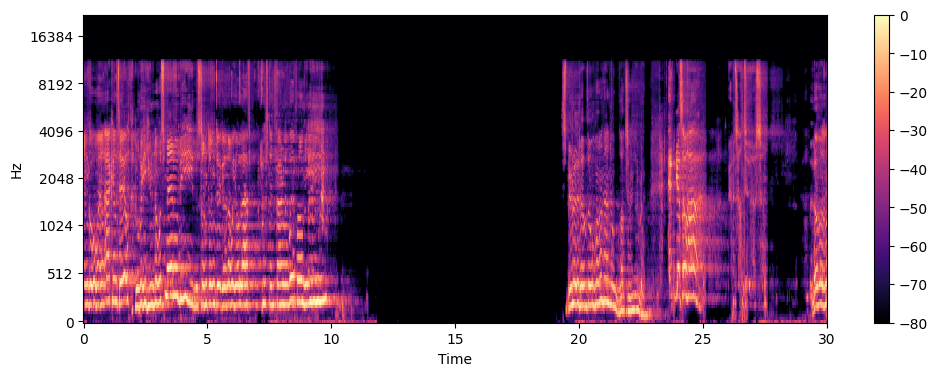

In [33]:
spec = librosa.feature.melspectrogram(y=audio, sr=sr)
spec_db = librosa.power_to_db(spec, ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(spec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.show()


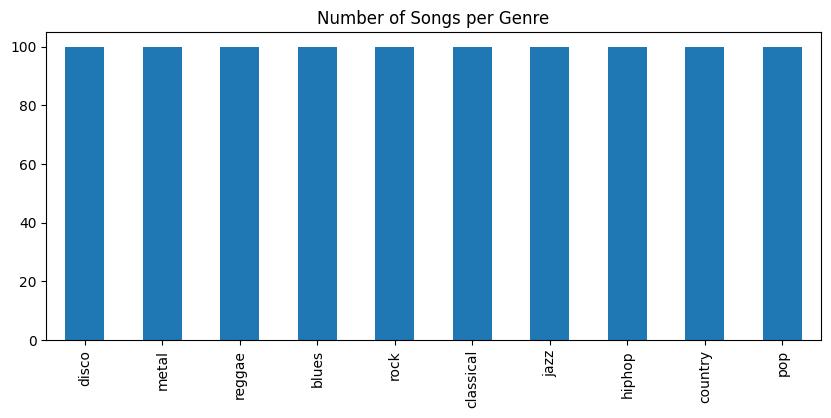

In [34]:
genre_counts = {}

for genre in os.listdir(GENRES_PATH):
    genre_counts[genre] = len(os.listdir(f"{GENRES_PATH}/{genre}"))

pd.Series(genre_counts).sort_values().plot(kind="bar", figsize=(10,4))
plt.title("Number of Songs per Genre")
plt.show()


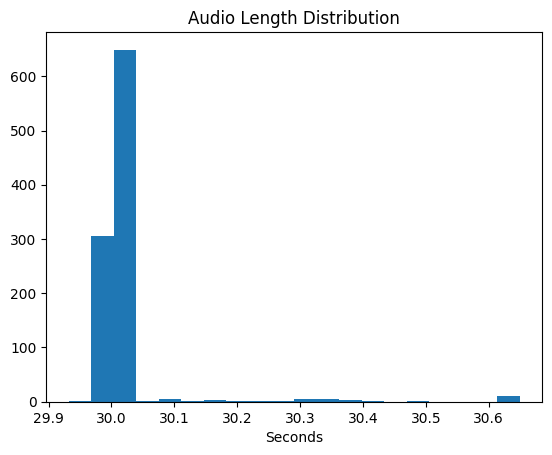

Mean length: 30.024047074829927


In [35]:
lengths = []

for genre in os.listdir(GENRES_PATH):
    songs = os.listdir(f"{GENRES_PATH}/{genre}")
    
    for song in songs:
        path = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
        if os.path.exists(path):
            audio, sr = librosa.load(path, sr=None)
            lengths.append(len(audio)/sr)

plt.hist(lengths, bins=20)
plt.title("Audio Length Distribution")
plt.xlabel("Seconds")
plt.show()

print("Mean length:", np.mean(lengths))


In [36]:
sample_rates = []

for genre in os.listdir(GENRES_PATH):
    songs = os.listdir(f"{GENRES_PATH}/{genre}")[:10]
    for song in songs:
        path = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
        if os.path.exists(path):
            _, sr = librosa.load(path, sr=None)
            sample_rates.append(sr)

pd.Series(sample_rates).value_counts()


44100    100
Name: count, dtype: int64

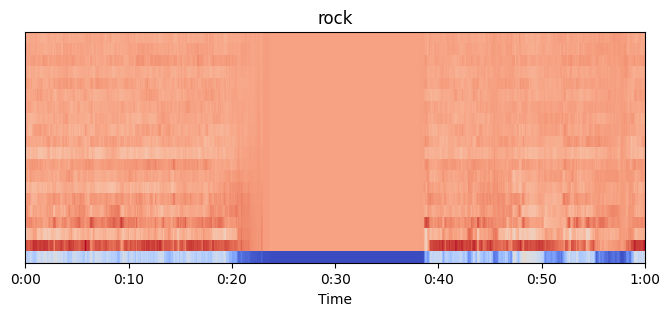

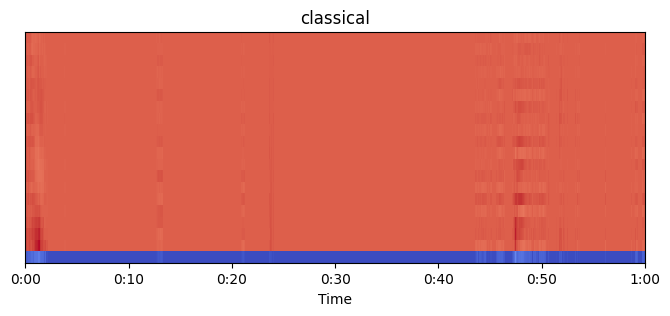

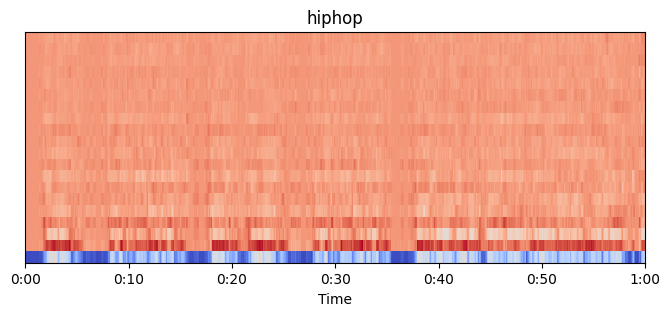

In [37]:
def plot_genre_mfcc(genre):
    song = os.listdir(f"{GENRES_PATH}/{genre}")[0]
    path = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
    audio, sr = librosa.load(path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    
    plt.figure(figsize=(8,3))
    librosa.display.specshow(mfcc, x_axis='time')
    plt.title(genre)
    plt.show()

plot_genre_mfcc("rock")
plot_genre_mfcc("classical")
plot_genre_mfcc("hiphop")


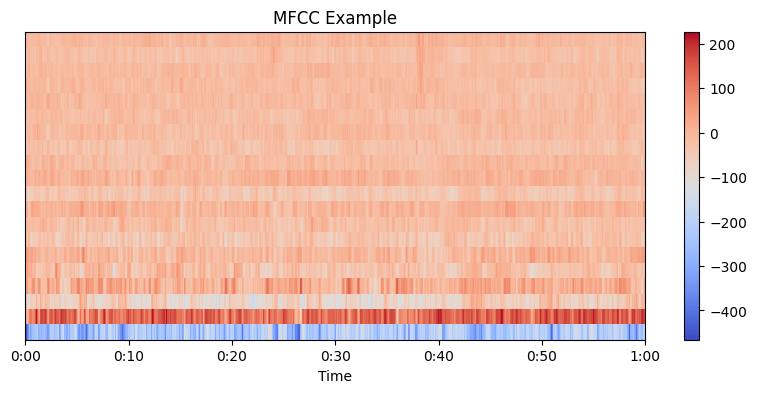

In [38]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Example")
plt.show()


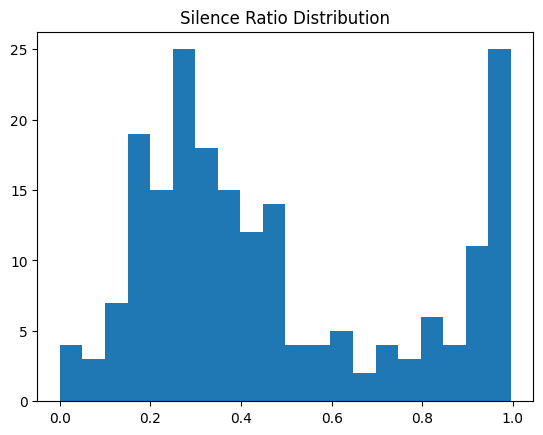

In [39]:
def silence_ratio(file_path):
    y, sr = librosa.load(file_path, sr=None)
    intervals = librosa.effects.split(y, top_db=20)
    voiced = sum((end-start) for start,end in intervals)
    return 1 - voiced/len(y)

ratios = []
for genre in os.listdir(GENRES_PATH):
    songs = os.listdir(f"{GENRES_PATH}/{genre}")[:20]
    for song in songs:
        path = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
        if os.path.exists(path):
            ratios.append(silence_ratio(path))

plt.hist(ratios, bins=20)
plt.title("Silence Ratio Distribution")
plt.show()


# Feature Extraction

In [40]:
def extract_features_song(song_folder):

    stems = ["drums.wav","vocals.wav","bass.wav","other.wav"]

    signals = []

    for stem in stems:

        file = f"{song_folder}/{stem}"

        y, sr = librosa.load(file, sr=22050)

        signals.append(y)

    mix = np.sum(signals,axis=0)

    mfcc = librosa.feature.mfcc(y=mix,sr=sr,n_mfcc=40)

    mfcc_mean = np.mean(mfcc,axis=1)
    mfcc_std = np.std(mfcc,axis=1)

    spec_cent = np.mean(
        librosa.feature.spectral_centroid(y=mix,sr=sr)
    )

    rolloff = np.mean(
        librosa.feature.spectral_rolloff(y=mix,sr=sr)
    )

    zcr = np.mean(
        librosa.feature.zero_crossing_rate(mix)
    )

    return np.concatenate([
        mfcc_mean,
        mfcc_std,
        [spec_cent,rolloff,zcr]
    ])


def extract_features(file_path):

    y, sr = librosa.load(file_path, sr=22050)

    mfcc = librosa.feature.mfcc(y=y,sr=sr,n_mfcc=40)

    mfcc_mean = np.mean(mfcc,axis=1)
    mfcc_std = np.std(mfcc,axis=1)

    spec_cent = np.mean(
        librosa.feature.spectral_centroid(y=y,sr=sr)
    )

    rolloff = np.mean(
        librosa.feature.spectral_rolloff(y=y,sr=sr)
    )

    zcr = np.mean(
        librosa.feature.zero_crossing_rate(y)
    )

    return np.concatenate([
        mfcc_mean,
        mfcc_std,
        [spec_cent,rolloff,zcr]
    ])

In [41]:
GENRES = sorted(os.listdir(GENRES_PATH))

STEMS = ["drums.wav","vocals.wav","bass.wav","other.wav"]

corrupted=0
small=0

for genre in GENRES:

    for song in os.listdir(f"{GENRES_PATH}/{genre}"):

        for stem in STEMS:

            fp=f"{GENRES_PATH}/{genre}/{song}/{stem}"

            if os.path.exists(fp):

                size=os.path.getsize(fp)

                if size<4096:
                    corrupted+=1

                if size<5*1024*1024:
                    small+=1

print("Corrupted files:",corrupted)
print("Small files:",small)

Corrupted files: 0
Small files: 0


In [42]:
silence_count=0

for genre in GENRES:

    songs=os.listdir(f"{GENRES_PATH}/{genre}")[:20]

    for song in songs:

        file=f"{GENRES_PATH}/{genre}/{song}/vocals.wav"

        y,sr=librosa.load(file,sr=None)

        if np.max(np.abs(y[:int(0.5*sr)]))<1e-4:

            silence_count+=1

print("Silence stems:",silence_count)

Silence stems: 20


In [43]:
durations=[]

for song in os.listdir(f"{GENRES_PATH}/jazz"):

    file=f"{GENRES_PATH}/jazz/{song}/vocals.wav"

    y,sr=librosa.load(file,sr=None)

    durations.append(len(y)/sr)

print("Mean Jazz Duration:",np.mean(durations))



Mean Jazz Duration: 30.032979591836728


# Build Training Dataset

In [44]:
X = []
y = []

SEGMENT_DURATION = 5
SR = 22050

for genre in GENRES:

    songs = os.listdir(f"{GENRES_PATH}/{genre}")

    for song in tqdm(songs):

        song_path = f"{GENRES_PATH}/{genre}/{song}"

        stems = ["drums.wav","vocals.wav","bass.wav","other.wav"]

        signals=[]

        for stem in stems:

            file=f"{song_path}/{stem}"

            y_audio, sr = librosa.load(file,sr=SR)

            signals.append(y_audio)

        mix=np.sum(signals,axis=0)

        segment_len = SEGMENT_DURATION*SR

        total_segments=len(mix)//segment_len

        for i in range(total_segments):

            segment=mix[i*segment_len:(i+1)*segment_len]

            mfcc=librosa.feature.mfcc(
                y=segment,
                sr=sr,
                n_mfcc=40
            )

            mfcc_mean=np.mean(mfcc,axis=1)
            mfcc_std=np.std(mfcc,axis=1)

            spec_cent=np.mean(
                librosa.feature.spectral_centroid(
                    y=segment,
                    sr=sr
                )
            )

            rolloff=np.mean(
                librosa.feature.spectral_rolloff(
                    y=segment,
                    sr=sr
                )
            )

            zcr=np.mean(
                librosa.feature.zero_crossing_rate(segment)
            )

            feat=np.concatenate([
                mfcc_mean,
                mfcc_std,
                [spec_cent,rolloff,zcr]
            ])

            X.append(feat)
            y.append(genre)


X=np.array(X)
y=np.array(y)

print("Dataset size:",X.shape)

100%|██████████| 100/100 [00:32<00:00,  3.08it/s]


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

# Logistic Regression Baseline

In [46]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X, y_encoded)


LogisticRegression(max_iter=1000)

In [47]:
def extract_dt_features(song_path):

    y,sr=librosa.load(song_path,sr=22050,duration=10)

    tempo,_=librosa.beat.beat_track(y=y,sr=sr)

    spec_cent=np.mean(
        librosa.feature.spectral_centroid(y=y,sr=sr)
    )

    zcr=np.mean(
        librosa.feature.zero_crossing_rate(y)
    )

    rolloff=np.mean(
        librosa.feature.spectral_rolloff(y=y,sr=sr)
    )

    return [tempo,spec_cent,zcr,rolloff]

# Neural Network Model (GPU)

In [48]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_val = torch.tensor(y_val, dtype=torch.long).to(device)


In [49]:
class GenreNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(83,512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512,256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,10)

        )

    def forward(self,x):

        return self.model(x)
model = GenreNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

In [50]:
for epoch in range(80):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs,y_train)

    loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_preds = model(X_val)

        val_loss = criterion(val_preds,y_val)

    print(f"Epoch {epoch+1} Loss {loss.item():.3f} Val {val_loss.item():.3f}")

Epoch 1 Loss 2.323 Val 2.277
Epoch 2 Loss 2.277 Val 2.234
Epoch 3 Loss 2.234 Val 2.192
Epoch 4 Loss 2.186 Val 2.149
Epoch 5 Loss 2.149 Val 2.106
Epoch 6 Loss 2.101 Val 2.061
Epoch 7 Loss 2.051 Val 2.014
Epoch 8 Loss 2.000 Val 1.966
Epoch 9 Loss 1.960 Val 1.920
Epoch 10 Loss 1.899 Val 1.874
Epoch 11 Loss 1.862 Val 1.829
Epoch 12 Loss 1.809 Val 1.785
Epoch 13 Loss 1.772 Val 1.742
Epoch 14 Loss 1.727 Val 1.700
Epoch 15 Loss 1.683 Val 1.657
Epoch 16 Loss 1.621 Val 1.614
Epoch 17 Loss 1.590 Val 1.572
Epoch 18 Loss 1.558 Val 1.531
Epoch 19 Loss 1.496 Val 1.492
Epoch 20 Loss 1.456 Val 1.454
Epoch 21 Loss 1.439 Val 1.418
Epoch 22 Loss 1.378 Val 1.385
Epoch 23 Loss 1.346 Val 1.354
Epoch 24 Loss 1.313 Val 1.325
Epoch 25 Loss 1.274 Val 1.299
Epoch 26 Loss 1.254 Val 1.274
Epoch 27 Loss 1.232 Val 1.250
Epoch 28 Loss 1.184 Val 1.228
Epoch 29 Loss 1.164 Val 1.207
Epoch 30 Loss 1.128 Val 1.188
Epoch 31 Loss 1.106 Val 1.171
Epoch 32 Loss 1.091 Val 1.155
Epoch 33 Loss 1.045 Val 1.139
Epoch 34 Loss 1.048

# Kaggle Submission

In [51]:
test_df = pd.read_csv(f"{DATA_PATH}/test.csv")
test_df.head()


,id,filename
0,1,mashups/song0001.wav
1,2,mashups/song0002.wav
2,3,mashups/song0003.wav
3,4,mashups/song0004.wav
4,5,mashups/song0005.wav


In [52]:
X_test = []

for fname in tqdm(test_df["filename"]):
    file_path = f"{DATA_PATH}/{fname}"
    features = extract_features(file_path)
    X_test.append(features)

X_test = scaler.transform(np.array(X_test))
print("X_test shape:", X_test.shape)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)


100%|██████████| 3020/3020 [06:54<00:00,  7.29it/s]

X_test shape: (3020, 83)


In [53]:
model.eval()

with torch.no_grad():
    preds = model(X_test_tensor)
    preds = torch.argmax(preds, axis=1).cpu().numpy()

pred_labels = le.inverse_transform(preds)

submission = pd.DataFrame({
    "id": test_df["id"],
    "genre": pred_labels
})

submission.to_csv("submission.csv", index=False)
submission.head()


,id,genre
0,1,pop
1,2,classical
2,3,hiphop
3,4,hiphop
4,5,hiphop


# Milestone 1


In [54]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import torch
import warnings
warnings.filterwarnings("ignore")


DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)

DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES_ROOT = f"{DATA_ROOT}/genres_stems"

GENRES = sorted(os.listdir(GENRES_ROOT))
STEMS = {"drums.wav":"drums","vocals.wav":"vocals","bass.wav":"bass","other.wav":"other"}
STEM_KEYS = ['drums','vocals','bass','other']

GENRE_TO_TEST = 'rock'
SONG_INDEX = 0


def build_dataset(root_dir, val_split=0.17, seed=42):
    train_dataset = {g: {k: [] for k in STEM_KEYS} for g in GENRES}
    val_dataset   = {g: {k: [] for k in STEM_KEYS} for g in GENRES}
    
    rng = random.Random(seed)
    corrupted_count = 0
    small_count = 0
    large_count = 0
    
    for genre in GENRES:
        genre_path = os.path.join(root_dir,"genres_stems",genre)
        songs = sorted(os.listdir(genre_path))
        valid_songs = []
        
        for song in songs:
            song_path = os.path.join(genre_path,song)
            valid=True
            
            for stem_file in STEMS.keys():
                fp = os.path.join(song_path,stem_file)
                
                if not os.path.exists(fp):
                    valid=False
                else:
                    size=os.path.getsize(fp)
                    
                    if size < 4*1024:
                        corrupted_count+=1
                        valid=False
                    
                    size_mb=size/(1024*1024)
                    if size_mb < 5.0491: small_count+=1
                    if size_mb > 5.0493: large_count+=1
            
            if valid:
                valid_songs.append(song)
        
        rng.shuffle(valid_songs)
        split=int(len(valid_songs)*(1-val_split))
        train_songs=valid_songs[:split]
        val_songs=valid_songs[split:]
        
        for s in train_songs:
            for stem_file,stem_key in STEMS.items():
                train_dataset[genre][stem_key].append(
                    os.path.join(genre_path,s,stem_file))
        
        for s in val_songs:
            for stem_file,stem_key in STEMS.items():
                val_dataset[genre][stem_key].append(
                    os.path.join(genre_path,s,stem_file))
    
    Q1 = corrupted_count + small_count
    Q2 = abs(large_count - small_count)
    Q3 = abs(len(train_dataset["reggae"]["drums"]) - len(val_dataset["country"]["vocals"]))
    
    return train_dataset, val_dataset, Q1, Q2, Q3

tr, val, Q1, Q2, Q3 = build_dataset(DATA_ROOT)

In [55]:
def find_long_silences(dataset_dict, sr=SR, threshold_sec=DURATION, top_db=TOP_DB):
    records = []

    for genre in dataset_dict:
        for stem in dataset_dict[genre]:
            for file_path in dataset_dict[genre][stem]:

                y, _ = librosa.load(file_path, sr=sr)

                total_duration = len(y) / sr

                rms = librosa.feature.rms(
                    y=y,
                    frame_length=N_FFT,
                    hop_length=HOP_LENGTH
                )[0]

                rms_db = librosa.amplitude_to_db(rms, ref=np.max)

                silent_frames = rms_db < -top_db

                silence_lengths = []
                count = 0

                for val in silent_frames:
                    if val:
                        count += 1
                    else:
                        if count > 0:
                            silence_lengths.append(count * HOP_LENGTH / sr)
                            count = 0

                if count > 0:
                    silence_lengths.append(count * HOP_LENGTH / sr)

                if len(silence_lengths) == 0:
                    continue

                max_silence = max(silence_lengths)

                if max_silence >= threshold_sec:

                    silence_type = []

                    if silence_lengths[0] >= threshold_sec:
                        silence_type.append("start")

                    if silence_lengths[-1] >= threshold_sec:
                        silence_type.append("end")

                    if max_silence >= threshold_sec and not silence_type:
                        silence_type.append("middle")

                    records.append({
                        "Genre": genre,
                        "Stem": stem,
                        "Duration": round(total_duration, 2),
                        "Max_Silence_Sec": round(max_silence, 2),
                        "Silence_Location": ", ".join(silence_type),
                        "File_Path": file_path
                    })

    columns = ["Genre","Stem","Duration","Max_Silence_Sec","Silence_Location","File_Path"]
    return pd.DataFrame(records, columns=columns)


In [56]:
df_silence = find_long_silences(tr)


Q4=len(df_silence)
Q5=len(df_silence[df_silence["Stem"]=="vocals"])
Q6=df_silence[df_silence["Stem"]=="vocals"]["Max_Silence_Sec"].mean()
Q7=len(df_silence[(df_silence["Genre"]=="jazz") & (df_silence["Stem"]=="drums")])
Q8=len(df_silence[(df_silence["Genre"]=="jazz") & (df_silence["Stem"]=="drums") & (df_silence["Silence_Location"]=="middle")])
Q9=len(df_silence[(df_silence["Genre"]=="jazz") & (df_silence["Stem"]=="drums") & (df_silence["Max_Silence_Sec"]>=10)])


stems_audio = []
for key in STEM_KEYS:
    file_path = tr[GENRE_TO_TEST][key][SONG_INDEX]
    y, _ = librosa.load(file_path, sr=SR, duration=DURATION)
    stems_audio.append(y)

stems_stack = np.vstack(stems_audio)

mix_raw = np.sum(stems_stack, axis=0)

rms_val = np.sqrt(np.mean(mix_raw ** 2))

peak_raw = np.max(np.abs(mix_raw))

mix_norm = mix_raw / peak_raw if peak_raw > 0 else mix_raw

Q10=len(mix_raw)
Q11=rms_val
Q12=np.max(np.abs(mix_raw))


print("\nFINAL ANSWERS:")
print("Q1:",Q1)
print("Q2:",Q2)
print("Q3:",Q3)
print("Q4:",Q4)
print("Q5:",Q5)
print("Q6:",Q6)
print("Q7:",Q7)
print("Q8:",Q8)
print("Q9:",Q9)
print("Q10:",Q10)
print("Q11:",Q11)
print("Q12:",Q12)


FINAL ANSWERS:
Q1: 1256
Q2: 1072
Q3: 66
Q4: 680
Q5: 304
Q6: 12.593059210526315
Q7: 24
Q8: 12
Q9: 7
Q10: 110250
Q11: 0.102124155
Q12: 0.58938766


## Milestone 2

In [57]:
ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
STEMS_PATH = f"{ROOT}/genres_stems"
NOISE_PATH = f"{ROOT}/ESC-50-master/audio"
MASHUPS_PATH = f"{ROOT}/mashups"

GENRES = ["blues","classical","country","disco","hiphop",
          "jazz","metal","pop","reggae","rock"]

In [58]:

durations=[]

for song in os.listdir(f"{STEMS_PATH}/jazz"):

    song_path=f"{STEMS_PATH}/jazz/{song}"

    for stem in ["drums.wav","vocals.wav","bass.wav","other.wav"]:

        file=f"{song_path}/{stem}"

        if os.path.exists(file):

            y,sr=librosa.load(file,sr=None)

            durations.append(len(y)/sr)

print("Q1 Mean Jazz Duration:",np.mean(durations))



sample_rates=set()

for root,_,files in os.walk(ROOT):

    for f in files:

        if f.endswith(".wav"):

            file=os.path.join(root,f)

            try:
                _,sr=librosa.load(file,sr=None)
                sample_rates.add(sr)
            except:
                pass

print("Q2 Sample Rates:",sorted(sample_rates))



empty_files=0

for root,_,files in os.walk(STEMS_PATH):

    for f in files:

        if f.endswith(".wav"):

            file=os.path.join(root,f)

            if os.path.getsize(file)==0:

                empty_files+=1

print("Q3 Empty Files:",empty_files)


db_vals=[]

for g in GENRES:

    for song in os.listdir(f"{STEMS_PATH}/{g}"):

        file=f"{STEMS_PATH}/{g}/{song}/vocals.wav"

        if os.path.exists(file):

            y,sr=librosa.load(file,sr=None)

            peak=np.max(np.abs(y))

            db=20*np.log10(peak+1e-9)

            db_vals.append(db)

print("Q4 Vocal Peak dB:",np.mean(db_vals))


centroids=[]

for song in os.listdir(f"{STEMS_PATH}/blues"):

    file=f"{STEMS_PATH}/blues/{song}/other.wav"

    if os.path.exists(file):

        y,sr=librosa.load(file,sr=None)

        c=np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))

        centroids.append(c)

print("Q5 Blues Centroid:",np.mean(centroids))



genre_centroids={}

for g in GENRES:

    vals=[]

    for song in os.listdir(f"{STEMS_PATH}/{g}"):

        file=f"{STEMS_PATH}/{g}/{song}/other.wav"

        if os.path.exists(file):

            y,sr=librosa.load(file,sr=None)

            c=np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))

            vals.append(c)

    genre_centroids[g]=np.mean(vals)

print("Q6 Highest Centroid Genre:",
      max(genre_centroids,key=genre_centroids.get))



silence_count=0

for g in GENRES:

    for song in os.listdir(f"{STEMS_PATH}/{g}"):

        for stem in ["drums.wav","vocals.wav","bass.wav","other.wav"]:

            file=f"{STEMS_PATH}/{g}/{song}/{stem}"

            if os.path.exists(file):

                y,sr=librosa.load(file,sr=None,duration=0.5)

                if np.max(np.abs(y))<1e-4:

                    silence_count+=1

print("Q7 Silence Stems:",silence_count)

Q1 Mean Jazz Duration: 30.032979591836728
Q2 Sample Rates: [22050, 44100]
Q3 Empty Files: 0
Q4 Vocal Peak dB: -12.49492
Q5 Blues Centroid: 1587.4632756559515
Q6 Highest Centroid Genre: hiphop
Q7 Silence Stems: 333


In [59]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score,confusion_matrix,classification_report

GENRES = ["blues","classical","country","disco","hiphop",
          "jazz","metal","pop","reggae","rock"]


def extract_dt_features(song_path):

    y,sr=librosa.load(f"{song_path}/other.wav",
                      sr=22050,
                      duration=10)

    tempo,_=librosa.beat.beat_track(y=y,sr=sr)

    spec_cent=np.mean(
        librosa.feature.spectral_centroid(y=y,sr=sr)
    )

    zcr=np.mean(
        librosa.feature.zero_crossing_rate(y)
    )

    rolloff=np.mean(
        librosa.feature.spectral_rolloff(y=y,sr=sr)
    )

    return [float(tempo),spec_cent,zcr,rolloff]


data=[]

for g in GENRES:

    gp=f"{STEMS_PATH}/{g}"

    songs=os.listdir(gp)

    for s in songs[:50]:

        data.append({
            "path":f"{gp}/{s}",
            "genre":g
        })

df=pd.DataFrame(data)

train_df,val_df=train_test_split(
    df,
    test_size=0.2,
    stratify=df['genre'],
    random_state=42
)


X_train=np.array([
    extract_dt_features(p)
    for p in train_df['path']
])

y_train=train_df['genre']


X_val=np.array([
    extract_dt_features(p)
    for p in val_df['path']
])

y_val=val_df['genre']


clf=DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

clf.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [60]:
y_pred=clf.predict(X_val)
macro_f1=f1_score(
    y_val,
    y_pred,
    average='macro'
)
cm=confusion_matrix(
    y_val,
    y_pred,
    labels=GENRES
)
cr=classification_report(
    y_val,
    y_pred
)
print("Macro F1:",macro_f1)
print("\nClassification Report\n")
print(cr)

Macro F1: 0.15230042016806722

Classification Report

              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



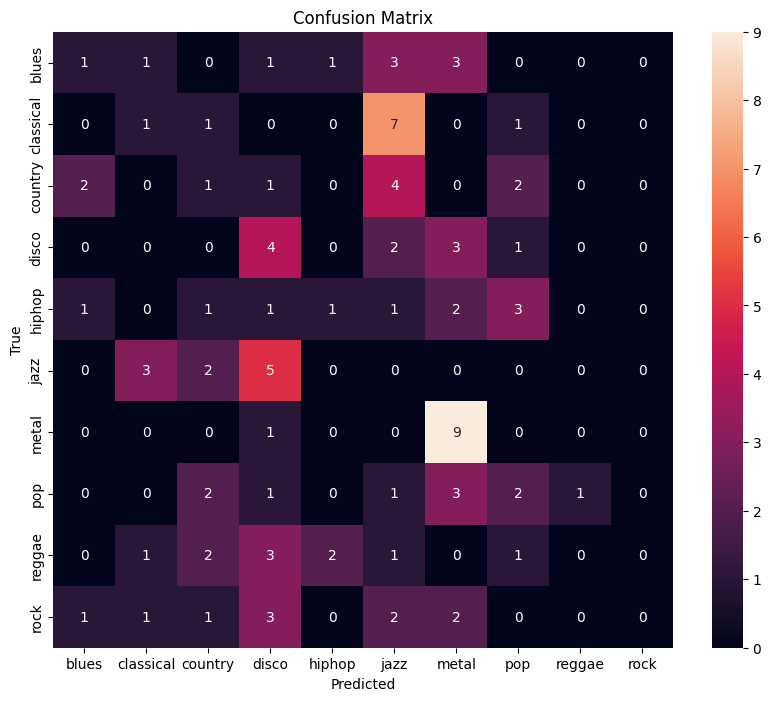

In [61]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=GENRES,
    yticklabels=GENRES
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [62]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_val,y_pred)

print("Accuracy:",accuracy)


tp={}
fn={}

total=np.sum(cm)

for i,g in enumerate(GENRES):

    TP=cm[i,i]

    FN=np.sum(cm[i,:])-TP

    tp[g]=TP
    fn[g]=FN


print("Highest TP:",max(tp,key=tp.get))

print("Lowest FN:",min(fn,key=fn.get))

Accuracy: 0.19
Highest TP: metal
Lowest FN: metal
